# Visualizing Vessel Movements on a World Map with the Vessel Tracking API and Python

This notebook is a companion to the Developer Community article *[Visualizing Vessel Movements on a World Map with the Vessel Tracking API and Python](https://developers.lseg.com/en/article-catalog/article/visualizing-vessel-movements-on-a-world-map-with-the-vessel-tracking-api-and-python)*.

## What you will learn

We will retrieve **historical vessel position snapshots** directly from the Vessel Tracking API's `/v1/Shipping/History` endpoint (see the *Vessel Tracking API Guide*). Each returned record represents a single AIS position report for a vessel at a point in time. 

In this notebook we will:

1. **Retrieve** historical vessel position data for a chosen IMO number from the Vessel Tracking API.
2. **Prepare** the data for analysis.
3. **Visualize** the vessel's route as a static plot of latitude/longitude points.
4. **Animate** the vessel's movement over time, replaying its historical track frame by frame, and save the result as a GIF.

This is a great starting point for anyone who wants to turn raw AIS position data into an intuitive, visual story of a vessel's voyage.


## 1. Install / Import Libraries

We need a small set of libraries:

- **pandas** — for loading and manipulating the tabular position data.
- **requests** — for calling the Vessel Tracking REST API.
- **matplotlib** — for plotting the route.
- **matplotlib.animation** — for animating the route playback and exporting it as a GIF.
- **cartopy** — for drawing the route on an actual world map (coastlines, land, ocean) instead of a plain chart.

If you don't have these installed yet, uncomment and run the `pip install` line below.

The API key is loaded from a `config.ini` file in the notebook's working directory:

```ini
[vessel_tracking]
api_key = apikey-v1 YOUR_API_KEY
```

Do not commit `config.ini` to source control.

In [ ]:
# Uncomment the line below if the required packages are not already installed in your environment.
# !pip install pandas matplotlib requests cartopy

import os

import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.crs as ccrs

import cartopy.feature as cfeature

In [2]:
from configparser import ConfigParser
from pathlib import Path

config_path = Path.cwd() / "config.ini"

config = ConfigParser()
if not config.read(config_path):
    raise FileNotFoundError(f"Configuration file not found: {config_path}")

API_KEY = config.get("vessel_tracking", "api_key")

## 2. Load Data from the Vessel Tracking API

We call the history endpoint for a single vessel:

```
GET /v1/Shipping/History?IMO=<imo>&FromDate=<from>&ToDate=<to>
```

The API key loaded from `config.ini` is supplied through the `Authorization` header. `FromDateTime` and `ToDateTime` are optional; commented examples are included in the code cell.

Each response record contains parallel `fieldNames` and `fieldValues` arrays. The code combines them into dictionaries, creates a pandas DataFrame, and converts the IMO and coordinate columns to numeric values.

In [3]:
# Vessel Tracking API configuration
BASE_URL = "https://vtracking.rdms.refinitiv.com/api/v1"
if not API_KEY:
    raise RuntimeError(
        "Set the VESSEL_TRACKING_API_KEY environment variable with your "
        "Vessel Tracking API key before running this notebook."
    )
HEADERS = {"Authorization": API_KEY, "Accept": "application/json"}

# Vessel and date range to retrieve (History only accepts a single IMO/RIC/ENI per call)
IMO = 9617698

params = {"IMO": IMO}

# Optional date range:
# params["FromDate"] = "2026-04-30T00:00:00Z"
# params["ToDate"] = "2026-04-30T23:59:59Z"

response = requests.get(
    f"{BASE_URL}/Shipping/History",
    params=params,
    headers=HEADERS,
    timeout=30,
)
response.raise_for_status()

# Each record comes back as {"fieldNames": [...], "fieldValues": [...]} rather than
# a flat object, so zip the two arrays together to get real column names.
records = response.json()
rows = [dict(zip(record["fieldNames"], record["fieldValues"])) for record in records]
df = pd.DataFrame(rows)

# All values arrive as strings, so cast the columns we do math/comparisons on to numbers.
df["IMO"] = pd.to_numeric(df["IMO"], errors="coerce")
df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")

df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")

df.head()
# Take a quick look at the retrieved data

,RIC,TimestampPosition,APICategoryName,IMO,ENI,MMSI,VesselName,VesselType,Deadweight,CallSign,...,AISDestMappedCountry,AISDestMappedLocode,AISDestMappedLocations,AISDestMappedOthers,IMOValid,PositionStatus,PositionStatusComment,ImportID,ImportTime,Status
0,C}KL7309527318,2026-09-22 03:21:29,Gas Tankers,9617698,,246878000,CORAL ENERGY,LNG Tankers,12268,PCQG,...,Iceland,ISREY,,,True,Published,,97e55ed2-35b6-f111-8575-068e461bdc07,2026-09-22 03:29:31,Permissioned
1,C}KL7309527318,2026-09-22 03:21:29,Gas Tankers,9617698,,246878000,CORAL ENERGY,LNG Tankers,12268,PCQG,...,Iceland,ISREY,,,True,Published,,b6695b41-36b6-f111-8575-068e461bdc07,2026-09-22 03:32:37,Permissioned
2,C}KL7309527318,2026-09-22 03:26:29,Gas Tankers,9617698,,246878000,CORAL ENERGY,LNG Tankers,12268,PCQG,...,Iceland,ISREY,,,True,Published,,edf721bd-36b6-f111-8575-068e461bdc07,2026-09-22 03:36:06,Permissioned
3,C}KL7309527318,2026-09-22 03:31:30,Gas Tankers,9617698,,246878000,CORAL ENERGY,LNG Tankers,12268,PCQG,...,Iceland,ISREY,,,True,Published,,5e915a17-37b6-f111-8575-068e461bdc07,2026-09-22 03:38:37,Permissioned
4,C}KL7309527318,2026-09-22 03:31:30,Gas Tankers,9617698,,246878000,CORAL ENERGY,LNG Tankers,12268,PCQG,...,Iceland,ISREY,,,True,Published,,1341d188-37b6-f111-8575-068e461bdc07,2026-09-22 03:41:46,Permissioned


## 3. Data Preparation

Before we can plot or animate anything, we need to clean up the data:

- Drop any rows that are missing coordinates or a timestamp — these can't be plotted.
- Convert `TimestampPosition` from text into a proper `datetime` type so that we can sort chronologically and format it for display.
- Print some quick summary statistics (row count, date range, number of distinct vessels) so we know what we're working with.

In [5]:
# Drop rows without valid coordinates or a timestamp — required for plotting
df = df.dropna(subset=["Latitude", "Longitude", "TimestampPosition"])

# Convert the timestamp column from text to a proper datetime type.
# The API returns timestamps in ISO-like "YYYY-MM-DD HH:MM:SS" format.
# errors="coerce" turns any unparseable values into NaT instead of raising an error.
df["TimestampPosition"] = pd.to_datetime(
    df["TimestampPosition"],
    errors="coerce"
)

# Drop any rows where the timestamp failed to parse
df = df.dropna(subset=["TimestampPosition"])

# Quick summary of the cleaned dataset
print(f"Row count       : {len(df)}")
print(f"Date range      : {df['TimestampPosition'].min()} to {df['TimestampPosition'].max()}")
print(f"Number of IMOs  : {df['IMO'].nunique()}")

Row count       : 366
Date range      : 2026-09-22 03:21:29 to 2026-09-23 02:05:54
Number of IMOs  : 1


## 4. Select and Order the Vessel Track

Although the API request already targets one IMO number, the DataFrame is filtered again as a safety check. The positions are then:

1. Sorted chronologically by `TimestampPosition`.
2. Thinned by retaining every third position, reducing the number of animation frames while preserving the route's overall shape.

In [6]:
# IMO was already used to scope the API request above; re-filter here as a safety net
track = (
    df[df["IMO"] == IMO]
    .sort_values("TimestampPosition")
    .iloc[::3]              # thin points for smoother, faster playback
    .reset_index(drop=True)
)

print(f"Number of position points for IMO {IMO}: {len(track)}")
track.head()


Number of position points for IMO 9617698: 122


,RIC,TimestampPosition,APICategoryName,IMO,ENI,MMSI,VesselName,VesselType,Deadweight,CallSign,...,AISDestMappedCountry,AISDestMappedLocode,AISDestMappedLocations,AISDestMappedOthers,IMOValid,PositionStatus,PositionStatusComment,ImportID,ImportTime,Status
0,C}KL7309527318,2026-09-22 03:21:29,Gas Tankers,9617698,,246878000,CORAL ENERGY,LNG Tankers,12268,PCQG,...,Iceland,ISREY,,,True,Published,,97e55ed2-35b6-f111-8575-068e461bdc07,2026-09-22 03:29:31,Permissioned
1,C}KL7309527318,2026-09-22 03:31:30,Gas Tankers,9617698,,246878000,CORAL ENERGY,LNG Tankers,12268,PCQG,...,Iceland,ISREY,,,True,Published,,5e915a17-37b6-f111-8575-068e461bdc07,2026-09-22 03:38:37,Permissioned
2,C}KL7309527318,2026-09-22 03:41:31,Gas Tankers,9617698,,246878000,CORAL ENERGY,LNG Tankers,12268,PCQG,...,Iceland,ISREY,,,True,Published,,883ef4c3-38b6-f111-8575-068e461bdc07,2026-09-22 03:50:36,Permissioned
3,C}KL7309527318,2026-09-22 03:56:32,Gas Tankers,9617698,,246878000,CORAL ENERGY,LNG Tankers,12268,PCQG,...,Iceland,ISREY,,,True,Published,,f2640548-3bb6-f111-8575-068e461bdc07,2026-09-22 04:08:37,Permissioned
4,C}KL7309527318,2026-09-22 04:08:38,Gas Tankers,9617698,,246878000,CORAL ENERGY,LNG Tankers,12268,PCQG,...,Iceland,ISREY,,,True,Published,,e8dedd8d-3cb6-f111-8575-068e461bdc07,2026-09-22 04:17:43,Permissioned


## 5. Basic Route Visualization

Before animating anything, let's plot the full route on an actual world map using Cartopy, rather than a plain `Longitude` vs `Latitude` chart. Cartopy draws real coastlines, land and ocean for the vessel's route, so the geography is immediately recognizable. This gives us a quick sanity check that the data looks correct and lets us see the overall shape of the vessel's voyage.

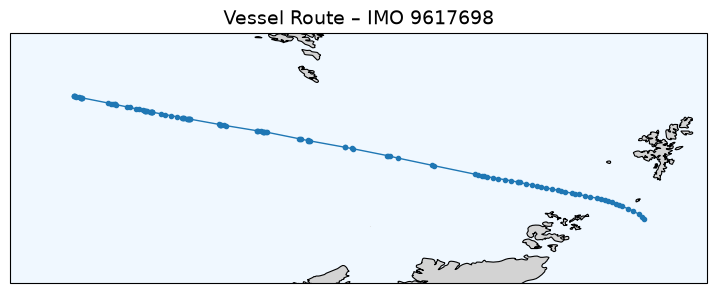

In [7]:
# A small margin around the route's bounding box, in degrees
pad = 1

fig = plt.figure(figsize=(9, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
    [
        track["Longitude"].min() - pad,
        track["Longitude"].max() + pad,
        track["Latitude"].min() - pad,
        track["Latitude"].max() + pad,
    ],
    crs=ccrs.PlateCarree(),
)

# Real-world basemap layers
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

ax.set_title(f"Vessel Route \u2013 IMO {IMO}", fontsize=14)
ax.plot(
    track["Longitude"], track["Latitude"],
    marker="o", markersize=3, lw=1,
    transform=ccrs.PlateCarree(),
)

plt.show()


## 6. Animated Route Playback

Now for the fun part — turning the static route into an animation. We'll use `matplotlib.animation.FuncAnimation` to:

- Gradually draw the route, one point at a time, as the animation progresses.
- Show the vessel's **current position** as a red marker that moves along the path.
- Display the **current timestamp** as a text annotation, so viewers can see when each position was recorded.

In [8]:
# Figure setup — same Cartopy basemap as the static plot above
pad = 1

fig = plt.figure(figsize=(9, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_title(f"Vessel Movement \u2013 IMO {IMO}", fontsize=14)

ax.set_extent(
    [
        track["Longitude"].min() - pad,
        track["Longitude"].max() + pad,
        track["Latitude"].min() - pad,
        track["Latitude"].max() + pad,
    ],
    crs=ccrs.PlateCarree(),
)

ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

# The route line (drawn gradually) and the current-position marker
line, = ax.plot([], [], lw=2, transform=ccrs.PlateCarree())
point, = ax.plot([], [], "ro", markersize=6, transform=ccrs.PlateCarree())

# Text annotation showing the current timestamp
time_text = ax.text(
    0.02, 0.95, "", transform=ax.transAxes,
    fontsize=10, bbox=dict(facecolor="white", alpha=0.7)
)


def init():
    """Reset all animated artists to an empty state at the start of the animation."""
    line.set_data([], [])
    point.set_data([], [])
    time_text.set_text("")
    return line, point, time_text


def update(frame):
    """Draw the route up to the current frame and move the marker to the latest position."""
    xs = track["Longitude"].iloc[:frame + 1]
    ys = track["Latitude"].iloc[:frame + 1]

    line.set_data(xs, ys)
    point.set_data(xs.iloc[-1:], ys.iloc[-1:])
    time_text.set_text(track["TimestampPosition"].iloc[frame].strftime("%d %b %Y %H:%M"))

    return line, point, time_text


ani = FuncAnimation(
    fig,
    update,
    frames=len(track),
    init_func=init,
    interval=80,     # milliseconds between frames
    repeat=False
)

plt.close(fig)  # prevent a duplicate static plot from being displayed below the animation


## 7. Save and Display the Animation

The completed animation is saved as a GIF using Pillow. The following cell then displays the saved GIF directly in the notebook.

In [9]:
output_path = "IMO_9617698_Movement.gif"
ani.save(output_path, writer="pillow")

print(f"Animation saved to: {output_path}")

Animation saved to: IMO_9617698_Movement.gif


Once saved, you can display the GIF directly in the notebook:

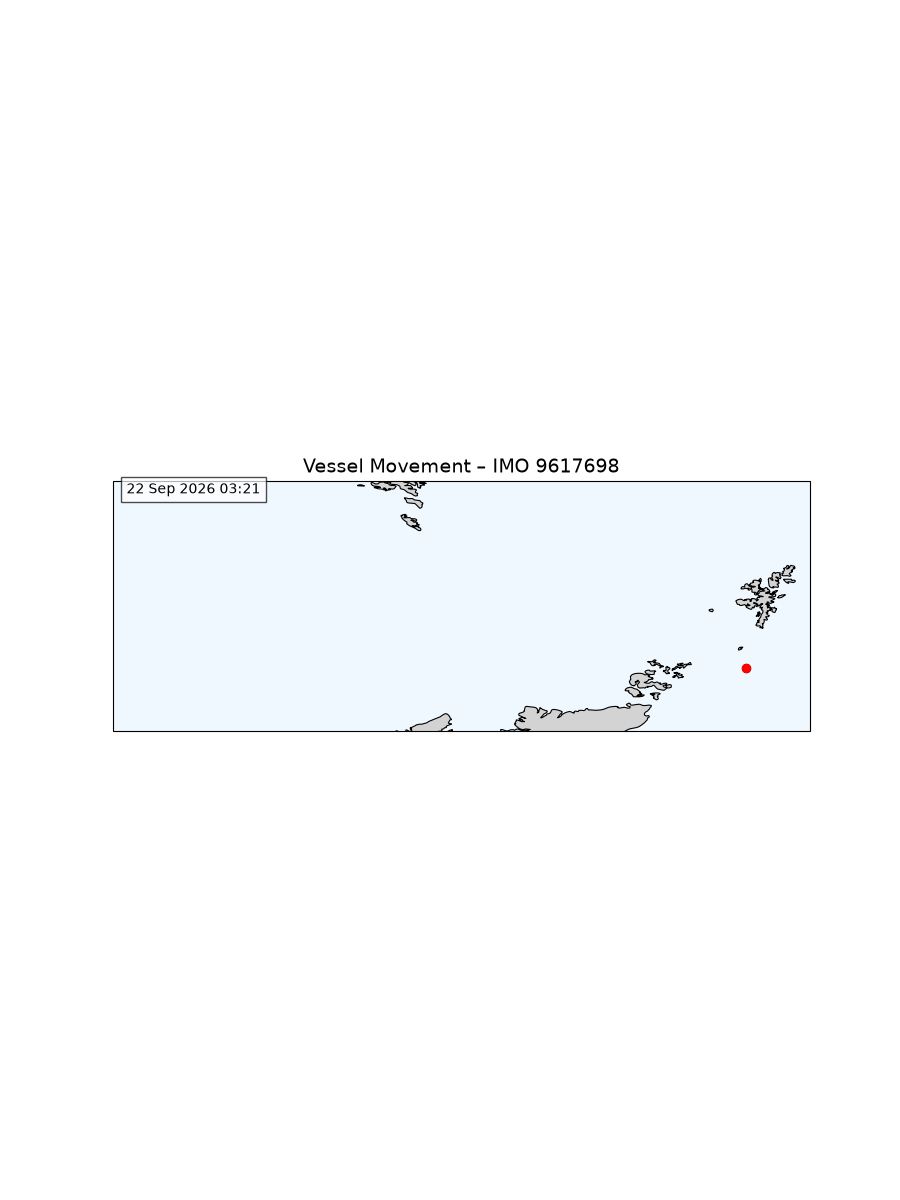

In [10]:
from IPython.display import Image

Image(filename=output_path)

## 8. Summary

In this notebook, we retrieved historical vessel position snapshots directly from the Vessel Tracking API and turned them into a visual story:

- Loaded and cleaned the raw position data (handling missing coordinates and parsing timestamps).
- Filtered the dataset down to a single vessel by IMO number and thinned the points for smoother playback.
- Plotted the vessel's route as a static chart for a quick sanity check.
- Animated the route playback, showing the vessel's position moving over time with a timestamp overlay.
- Exported the animation as a shareable GIF file.

### What's next?

This notebook works with **historical** (already-recorded) position data pulled in bulk. A natural next step would be to connect to the Vessel Tracking API's **WebSocket push interface** to receive position updates in near real time, and update the visualization live as new positions arrive — rather than replaying a fixed historical dataset. That would turn this from a "replay" tool into a genuine live vessel-tracking dashboard.